# Indexing a phantom from scratch

`anri.index` finds each voxel's orientations in scanning 3DXRD data with no grains, tomography or point-by-point map to start from: only the phase and the data.
Instead of scoring voxels one at a time, it fits every voxel's orientations at once with the forward model, so that voxels sharing a beam path don't bias each other.

The steps:

1. **Rings and data.** The sparse pixels are binned once into a coarse histogram `H[ring, eta, omega, dty row]`, and a row-summed "lit" map of where there is intensity.
2. **Pruning.** An orientation grid covers one fundamental zone of the crystal's Laue group. Each orientation's *completeness*, the fraction of its predicted spots that land on lit bins, decides which orientations are kept. The matching tolerances come from the grid spacing and the data.
3. **Occupancy.** The data are linear in the sample's density over position and orientation, `d = A f`. Each voxel keeps its best candidate orientations, and their occupancies are fitted by MLEM to the histogram, every voxel jointly.
4. **Populations.** Each voxel's occupancy is grouped into orientation populations (a grain, its twin, ...) with fractions, mean orientations and spreads.

Here we render the [phantom](phantom.ipynb) as a scanning-3DXRD dataset with Anri's renderer, write it as an ImageD11 dataset, index it with the functions of `anri.index`, and compare with the truth.
`python -m anri.index <analysisroot> <sample> <dataset>` runs the same steps on any ImageD11 dataset.

This runs in a few minutes on a laptop CPU. It is stored with its outputs and is not re-run when the docs are built.

In [1]:
import anri.utils

anri.utils.setup()  # before any JAX computation

import os
import tempfile
import time

import h5py
import jax.numpy as jnp
import numpy as np
from ImageD11.sinograms.tensor_map import TensorMap
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

import anri.crystal
import anri.geom
import anri.index as X
import anri.io

start = time.time()

## The phantom

A 316L-like stainless steel slice: 38 grains in a disk of radius 25 µm, cells of about 1.5 µm misoriented by a few tenths of a degree, and twin lamellae in the largest grain, on a grid of 0.5 µm voxels.

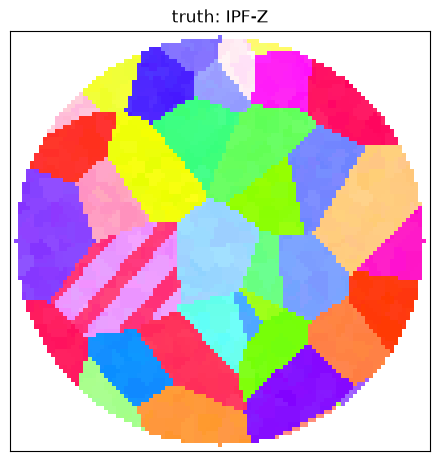

In [2]:
truth = TensorMap.from_h5(os.path.join("..", "..", "..", "tests", "data", "phantoms", "am316l", "am316l_tmap.h5"))
truth.get_ipf_maps()
a = truth.phases[0].lattice_parameters[0]
crystal = anri.crystal.Crystal(anri.crystal.UnitCell.from_lpars([a, a, a, 90.0, 90.0, 90.0]),
                               anri.crystal.Symmetry.from_number(225))
B = np.asarray(crystal.B, np.float32)
ops = anri.crystal.laue_rotations(np.asarray(crystal.sym_ops), B)
inside = truth.phase_ids[0] >= 0
fig, ax = plt.subplots(figsize=(4.5, 4.5), layout="constrained")
ax.imshow(np.where(inside[..., None], truth.ipf_z[0], 1.0), origin="lower")
ax.set_title("truth: IPF-Z")
ax.set_xticks([]), ax.set_yticks([])
plt.show()

## Simulating the scan

A pencil beam of 1.4 µm FWHM, dty from −30 to 30 µm in 1 µm steps, 1800 frames of 0.1° over 180°, a 2048 × 2048 detector of 75 µm pixels 150 mm from the sample, at the Tognan wavelength (0.2843 Å).
`anri.io.entries_from_tensormap` turns the phantom into map entries for the renderer, and `anri.io.simulate_sparse` renders every dty row into an ImageD11 sparse file, rounded to integer counts.
`write_pars` and `write_dataset` complete an ImageD11 dataset.

In [3]:
wl = 0.2843
pars = {
    "y_center": 1023.5, "y_size": 75.0, "tilt_y": 1e-3, "z_center": 1023.5, "z_size": 75.0, "tilt_z": -2e-3,
    "tilt_x": 0.0, "distance": 150e3, "o11": -1, "o12": 0, "o21": 0, "o22": -1, "wavelength": wl, "wedge": 0.0,
    "chi": 0.0, "omegasign": 1.0, "t_x": 0.0, "t_y": 0.0, "t_z": 0.0,
}
y0 = 0.3  # the rotation axis is a little off the middle row
geom = anri.io.geom_from_pars(pars, y0, wl * 2e-4 / 2.355, 5e-5, 5e-5, sig_beam=1.4 / 2.355, voxel_size=0.5, sig_psf=0.5)

entries = anri.io.entries_from_tensormap(truth)
entries["density"] = np.full(len(entries["pos"]), 30.0)  # counts scale
rings8 = X.ring_table(crystal, wl, 8)  # every allowed reflection up to the 8th ring
omega, dty = anri.io.motor_grid((0.0, 180.0), 0.1, (y0 - 30.0, y0 + 30.0), 1.0)
print(f"{len(entries['pos'])} entries, {len(rings8['hkls'])} hkls in 8 rings, {omega.shape[0]} rows x {omega.shape[1]} frames")

tmp = tempfile.mkdtemp()
sparse = os.path.join(tmp, "phantom_sparse.h5")
t0 = time.time()
stats = anri.io.simulate_sparse(sparse, entries, rings8["hkls"], np.ones(len(rings8["hkls"])), geom, omega, dty, (2048, 2048))
cell = {"cell__a": a, "cell__b": a, "cell__c": a, "cell_alpha": 90.0, "cell_beta": 90.0, "cell_gamma": 90.0,
        "cell_lattice_[P,A,B,C,I,F,R]": 225}
parfile = anri.io.write_pars(os.path.join(tmp, "pars"), pars, {"316L": cell})
dsfile = anri.io.write_dataset(sparse, tmp, "phantom", "am316l", y0=y0, parfile=parfile)
print(f"rendered {stats['n_pixels'].sum() / 1e6:.1f}M pixels in {time.time() - t0:.0f} s -> {dsfile}")

7845 entries, 112 hkls in 8 rings, 61 rows x 1800 frames


rendered 2.4M pixels in 63 s -> /tmp/tmpppj7ixfs/phantom/phantom_am316l/phantom_am316l_dataset.h5


What the detector sees in the middle row, all 1800 frames summed (binned 4 x 4 so that the spots show).

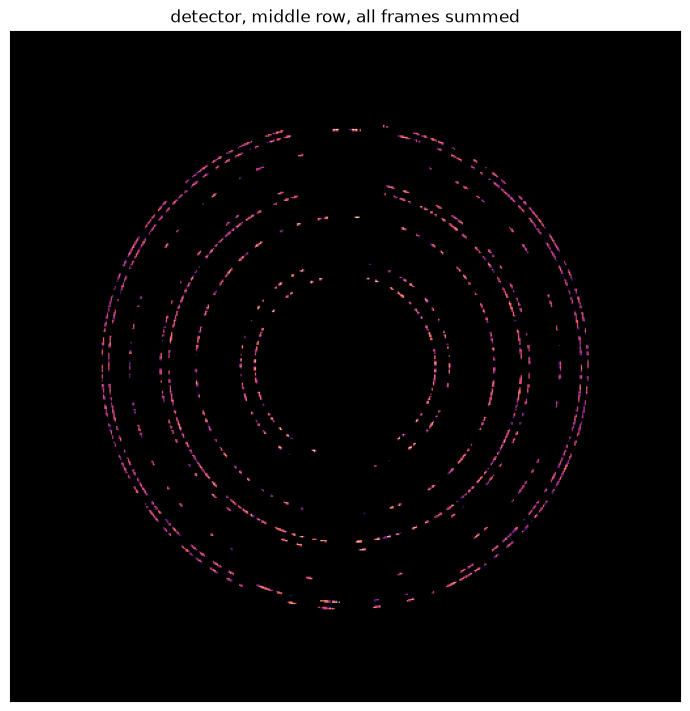

In [4]:
det = np.zeros(2048 * 2048)
with h5py.File(sparse, "r") as h:
    g = h[f"{omega.shape[0] // 2 + 1}.1"]
    np.add.at(det, g["row"][()].astype(int) * 2048 + g["col"][()], g["intensity"][()].astype(float))
det = det.reshape(512, 4, 512, 4).sum((1, 3))
cmap = plt.get_cmap("magma").copy()
cmap.set_bad("black")
fig, ax = plt.subplots(figsize=(7, 7), layout="constrained")
ax.imshow(np.ma.masked_equal(det, 0), norm=LogNorm(1, None), cmap=cmap, origin="lower")
ax.set_title("detector, middle row, all frames summed")
ax.set_xticks([]), ax.set_yticks([])
plt.show()

## 1. Rings and the data

From here on we use only the dataset files, as for a real experiment.
`anri.io.read_dataset` and `read_pars_json` read the scan and the phase, and `stream_sparse` reads the pixels a chunk at a time.
We use the first six rings. Their widths are measured from a few rows: they set the 2θ window of each ring, and how far a spot can move in η across it.

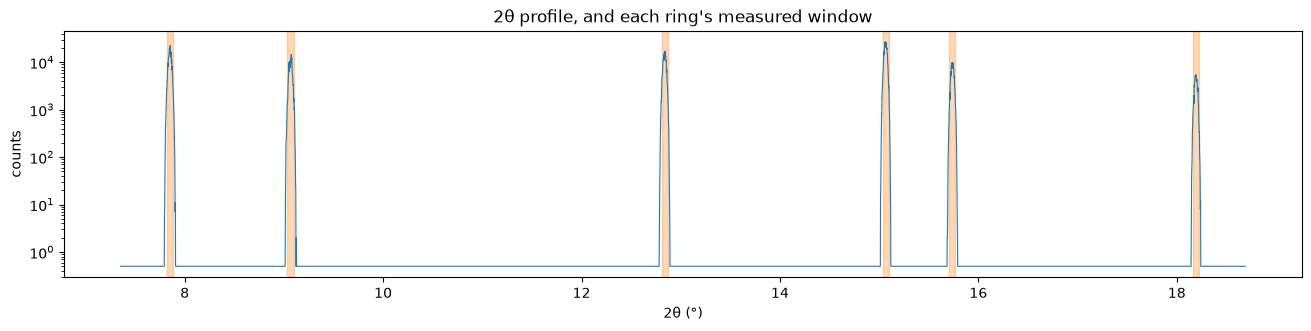

half-widths (°): [0.032 0.033 0.03  0.03  0.03  0.03 ]


In [5]:
ds = anri.io.read_dataset(dsfile)
geo, phase, cell = anri.io.read_pars_json(ds["parfile"])
geom = anri.io.geom_from_pars(geo, ds["y0"], wl * 2e-3 / 2.355, 1.5e-4, 1.5e-4, sig_beam=1.0, voxel_size=1.0)
geom = {k: jnp.asarray(v, jnp.float32) if np.issubdtype(np.asarray(v).dtype, np.floating) else v for k, v in geom.items()}
rings = X.ring_table(crystal, geo["wavelength"], 6)
chunk = 1 << 20

def stream(groups=None):
    return anri.io.stream_sparse(sparse, ds["ybinedges"], ds["omegamotor"], ds["dtymotor"], chunk, groups)

# the 2theta profile of a few rows, and each ring's width
lo, step = float(rings["tth"][0]) - 0.5, 0.002
n = int(np.ceil((float(rings["tth"][-1]) + 0.5 - lo) / step))
prof = jnp.zeros(n)
for slow, fast, om, _, val in stream([f"{k}.1" for k in (16, 31, 46)]):
    prof += X.tth_profile(X.pixel_angles(jnp.asarray(slow), jnp.asarray(fast), jnp.asarray(om), geom), jnp.asarray(val), lo, step, n)
offset, hw = X.ring_widths(np.asarray(prof), lo, step, rings["tth"])
rings["hw"] = hw
tth_tol = np.abs(offset) + hw

x = lo + (np.arange(n) + 0.5) * step
fig, ax = plt.subplots(figsize=(13, 3.2), layout="constrained")
ax.semilogy(x, np.maximum(np.asarray(prof), 0.5), lw=0.8)
for t, w in zip(rings["tth"], tth_tol):
    ax.axvspan(t - w, t + w, color="tab:orange", alpha=0.3)
ax.set_xlabel("2θ (°)")
ax.set_ylabel("counts")
ax.set_title("2θ profile, and each ring's measured window")
plt.show()
print("half-widths (°):", np.round(hw, 3))

The pixels go once into two histograms: the lit map (0.5° in η, 0.25° in ω, all rows summed) for pruning, and the data for the occupancy fit (1° × 1°, per dty row).

histograms: 6 s


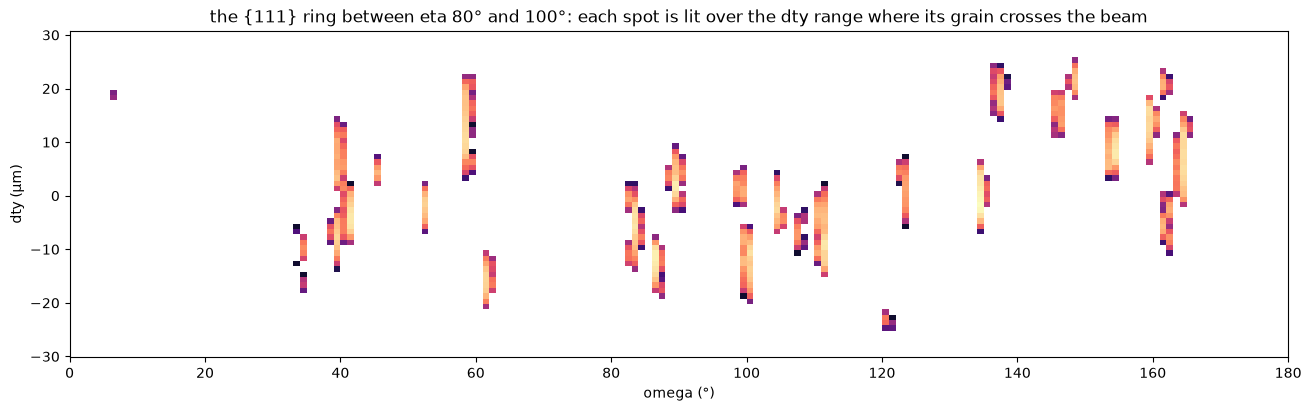

lit: 0.7% of (ring, eta, omega) bins


In [6]:
om0, ostep = float(ds["obinedges"][0]), float(np.median(np.diff(ds["obinedges"])))
nk = len(ds["ybincens"])
lit_bins, bins = (0.5, 0.25, 720, 720), (1.0, 1.0, 360, 180)
t0 = time.time()
H_lit = X.histogram_pixels(stream(), geom, rings["tth"], tth_tol, om0, lit_bins, 1, chunk).reshape(6, 720, 720)
H = X.histogram_pixels(stream(), geom, rings["tth"], tth_tol, om0, bins, nk, chunk)
print(f"histograms: {time.time() - t0:.0f} s")

# a sinogram from the histogram: the first ring, eta from 80 to 100 degrees, every dty row
H4 = np.asarray(H).reshape(6, 360, 180, nk)
fig, ax = plt.subplots(figsize=(13, 4), layout="constrained")
ax.imshow(H4[0, 260:280].sum(0).T, aspect="auto", origin="lower", cmap="magma", norm=LogNorm(1, None),
          extent=(om0, om0 + 180, ds["ybincens"][0] - 0.5, ds["ybincens"][-1] + 0.5))
ax.set_xlabel("omega (°)")
ax.set_ylabel("dty (µm)")
ax.set_title("the {111} ring between eta 80° and 100°: each spot is lit over the dty range where its grain crosses the beam")
plt.show()

med = float(jnp.median(H_lit[H_lit > 0]))
lit = {"table": X.lit_table(H_lit > med), "om0": om0, "bins": lit_bins, "frame_step": ostep, "etacut": 0.2}
print(f"lit: {float(jnp.mean(H_lit > med)) * 100:.1f}% of (ring, eta, omega) bins")

## 2. Pruning

The cubic grid is a regular Rodrigues grid of the fundamental zone (other symmetries use a cubochoric grid, `anri.crystal.orientation_grid`).
A coarser grid needs larger tolerances, so more orientations match by chance. `choose_grid` measures the chance completeness (the median over a sample of the grid: most grid orientations are wrong) for a few steps.

grid 3.0°: 31573 orientations, at most 2.60° from any orientation; chance completeness 0.41


grid 2.5°: 52825 orientations, at most 2.17° from any orientation; chance completeness 0.33


grid 2.0°: 106532 orientations, at most 1.73° from any orientation; chance completeness 0.26


grid 1.5°: 252264 orientations, at most 1.30° from any orientation; chance completeness 0.19


grid 1.0°: 829249 orientations, at most 0.87° from any orientation; chance completeness 0.13


grid 2.0°: 1233 of 106532 orientations at completeness >= 0.63 (chance 0.26)


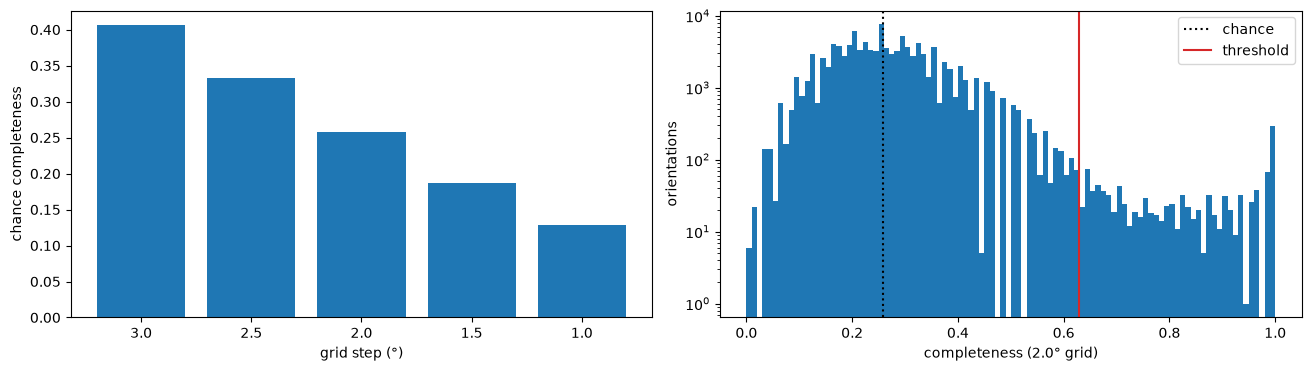

In [7]:
chance = {}
for s in X.GRID_STEPS:
    U_s, d_s = anri.crystal.orientation_grid(s, ops)
    sample = U_s[np.random.default_rng(0).choice(len(U_s), 8000, replace=False)]
    chance[s] = float(np.median(X.completeness_of(sample, d_s, B, rings, geom, lit)))
    print(f"grid {s}°: {len(U_s)} orientations, at most {d_s:.2f}° from any orientation; chance completeness {chance[s]:.2f}")

step = 2.0  # the coarsest step with chance completeness below 0.3 (choose_grid does this)
U_grid, delta = anri.crystal.orientation_grid(step, ops)
kept, comp, info = X.prune(U_grid, delta, B, rings, geom, lit)
U_kept = U_grid[kept]
print(f"grid {step}°: {info['n_above']} of {len(U_grid)} orientations at completeness >= {info['min_comp']:.2f} "
      f"(chance {info['chance']:.2f})")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6), layout="constrained")
ax[0].bar([str(s) for s in chance], list(chance.values()), color="tab:blue")
ax[0].set_xlabel("grid step (°)")
ax[0].set_ylabel("chance completeness")
ax[1].hist(comp, bins=100, log=True, color="tab:blue")
ax[1].axvline(info["chance"], color="k", ls=":", label="chance")
ax[1].axvline(info["min_comp"], color="tab:red", label="threshold")
ax[1].set_xlabel(f"completeness ({step}° grid)")
ax[1].set_ylabel("orientations")
ax[1].legend()
plt.show()

## 3. Occupancy

The kept orientations' predictions, then the fit on ImageD11's reconstruction grid (1 µm voxels, centred on the rotation axis).
Each voxel's 64 best candidates come from the first MLEM update from flat occupancy; MLEM then fits their occupancies, every voxel at once.

In [8]:
pred = X.predictions(U_kept, B, rings, geom, etacut=0.2)
ystep = float(np.median(np.diff(ds["ybincens"])))
_, pad = anri.geom.sino_shift_and_pad(ds["y0"], nk, float(ds["ybincens"][0]), ystep)
nr = nk + pad
pos = np.asarray(anri.geom.recon_positions(nr, ystep), np.float32)
scan = {"y0": ds["y0"], "dty0": float(ds["ybincens"][0]), "ystep": ystep, "n_rows": nk, "om0": om0}
t0 = time.time()
f, cand = X.fit_occupancy(H, pred, rings["ring_j"], pos, scan, bins, k=64, n_iter=10)
print(f"occupancy: {time.time() - t0:.0f} s")

candidates: 3969 voxels x 1248 orientations, the top 64 per voxel


  candidates: A 1 over 4 blocks of 1024 voxels: 27.9 s


  candidates: top 64 per voxel: 16.3 s
candidates: 44.3 s


  MLEM 0: deviance 6.761e+08


  MLEM 5: deviance 6.31e+08


  MLEM 9: deviance 6.3e+08
MLEM 10 iterations: 29.8 s
occupancy: 74 s


## 4. Populations

Each voxel's occupied candidates are grouped into populations: candidates within 1.8 grid steps of the most occupied one join it, the next most occupied free one starts the next population, and so on.
Each population has a fraction of the voxel, a mean orientation, a spread (which includes the grid's own spacing) and a completeness. Populations below 10% of a voxel are not reported.

In [9]:
tot = f.sum(1)
occupied = tot > 0.2 * np.percentile(tot, 99)  # the sample; the raw occupancy is kept
frac, U_pop, spread, _ = X.populations(f, cand, U_kept, ops, 1.8 * step)
present = (frac >= 0.1) & occupied[:, None]
present[:, 0] = occupied
n_pop = present.sum(1)
print(f"{occupied.sum()} voxels occupied; populations per voxel: "
      + ", ".join(f"{k}: {np.mean(n_pop[occupied] == k) * 100:.0f}%" for k in range(1, 5)))

maps = {
    "UBI": np.where(occupied[:, None, None], np.linalg.inv(U_pop[:, 0] @ B), np.nan).reshape(nr, nr, 3, 3),
    "phase_ids": np.where(occupied, 0, -1).reshape(nr, nr),
    "occupancy": tot.reshape(nr, nr),
    "n_populations": n_pop.reshape(nr, nr),
    "fraction": frac[:, 0].reshape(nr, nr),
    "second_fraction": np.where(present[:, 1], frac[:, 1], 0.0).reshape(nr, nr),
    "spread": spread[:, 0].reshape(nr, nr),
}
result = anri.io.tensormap_from_recon(maps, [a, a, a, 90.0, 90.0, 90.0], 225, "316L", ystep)
result.get_ipf_maps()

2028 voxels occupied; populations per voxel: 1: 58%, 2: 37%, 3: 4%, 4: 0%


## Against the truth

Each phantom voxel (0.5 µm) is compared with the indexed voxel (1 µm) it lies in: the misorientation to the main population, and to the closest of the voxel's populations (so a twin found as a second population counts).

main population vs truth: median 0.53°, within 1°: 88.1%, within 2°: 90.1%
closest population vs truth: within 1°: 96.4%


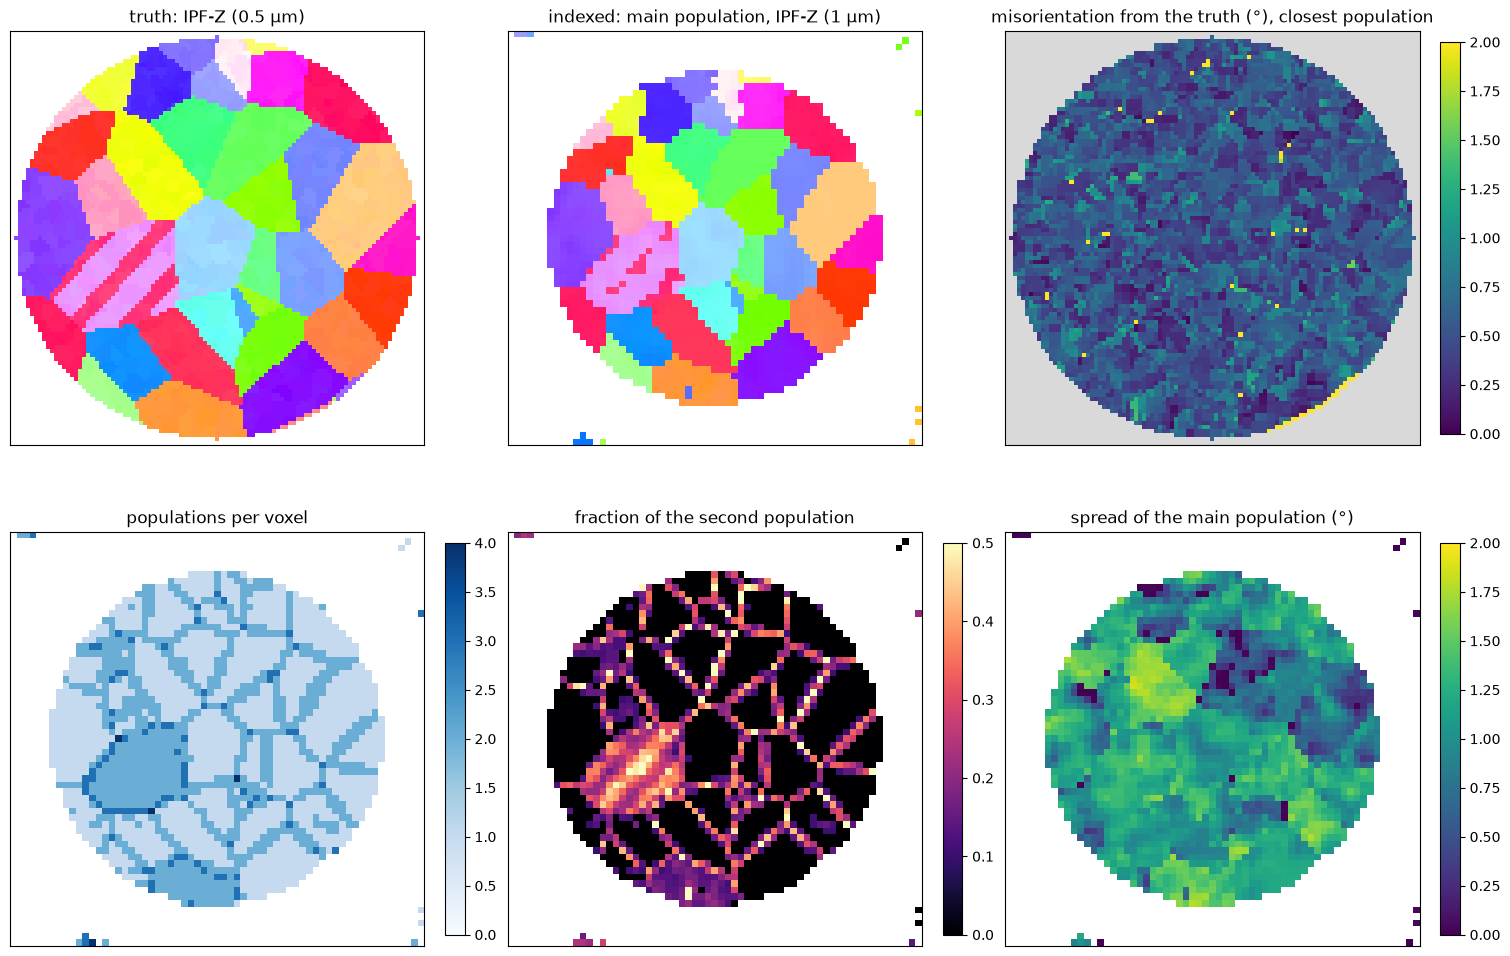

In [10]:
tp = anri.io.entries_from_tensormap(truth)
U_true = np.linalg.inv(tp["ubi"]) @ np.linalg.inv(B)  # U B = UBI^-1; B is diagonal here
near = np.argmin(np.linalg.norm(tp["pos"][:, None, :2] - pos[None, :, :2], axis=2), 1)
err = np.stack([anri.crystal.disorientation(U_pop[near, p], U_true, ops) for p in range(4)], 1)
err = np.where(present[near], err, np.inf)
print(f"main population vs truth: median {np.median(err[:, 0]):.2f}°, within 1°: {np.mean(err[:, 0] < 1) * 100:.1f}%, "
      f"within 2°: {np.mean(err[:, 0] < 2) * 100:.1f}%")
print(f"closest population vs truth: within 1°: {np.mean(err.min(1) < 1) * 100:.1f}%")

# each phantom voxel's misorientation to the closest population of the indexed voxel it lies in, on the phantom's grid
n_t = truth.shape[1]
ri, rj = np.nonzero(TensorMap.map_order_to_recon_order(truth.phase_ids, 0) == 0)  # as entries_from_tensormap
err_r = np.full((n_t, n_t), np.nan)
err_r[ri, rj] = np.where(np.isfinite(err.min(1)), err.min(1), np.nan)  # NaN: not indexed
truth.add_map("error", TensorMap.recon_order_to_map_order(err_r))

fig, ax = plt.subplots(2, 3, figsize=(15, 10), layout="constrained")
mask = result.phase_ids[0] >= 0
ax[0, 0].imshow(np.where(inside[..., None], truth.ipf_z[0], 1.0), origin="lower")
ax[0, 0].set_title("truth: IPF-Z (0.5 µm)")
ax[0, 1].imshow(np.where(mask[..., None], result.ipf_z[0], 1.0), origin="lower")
ax[0, 1].set_title("indexed: main population, IPF-Z (1 µm)")
im = ax[0, 2].imshow(truth.error[0], origin="lower", cmap="viridis", vmin=0, vmax=2)
ax[0, 2].set_title("misorientation from the truth (°), closest population")
ax[0, 2].set_facecolor("0.85")
fig.colorbar(im, ax=ax[0, 2], shrink=0.8)
im = ax[1, 0].imshow(np.where(mask, result.n_populations[0], np.nan), origin="lower", cmap="Blues", vmin=0, vmax=4)
ax[1, 0].set_title("populations per voxel")
fig.colorbar(im, ax=ax[1, 0], shrink=0.8)
im = ax[1, 1].imshow(np.where(mask, result.second_fraction[0], np.nan), origin="lower", cmap="magma", vmin=0, vmax=0.5)
ax[1, 1].set_title("fraction of the second population")
fig.colorbar(im, ax=ax[1, 1], shrink=0.8)
im = ax[1, 2].imshow(np.where(mask, result.spread[0], np.nan), origin="lower", cmap="viridis", vmin=0, vmax=2)
ax[1, 2].set_title("spread of the main population (°)")
fig.colorbar(im, ax=ax[1, 2], shrink=0.8)
for a_ in ax.ravel():
    a_.set_xticks([]), a_.set_yticks([])
plt.show()

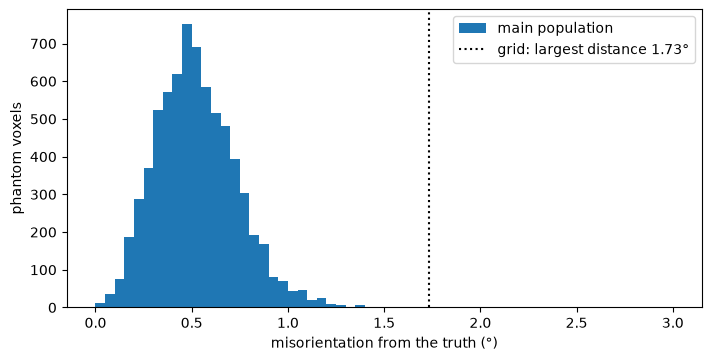

total time: 154 s


In [11]:
fig, ax = plt.subplots(figsize=(7, 3.5), layout="constrained")
ax.hist(err[:, 0][np.isfinite(err[:, 0])], bins=np.linspace(0, 3, 61), color="tab:blue", label="main population")
ax.axvline(delta, color="k", ls=":", label=f"grid: largest distance {delta:.2f}°")
ax.set_xlabel("misorientation from the truth (°)")
ax.set_ylabel("phantom voxels")
ax.legend()
plt.show()
print(f"total time: {time.time() - start:.0f} s")

## What this shows, and what is next

- Every grain is found from nothing, with no grain-level step: the grain shapes come out of the occupancy, and the main population's mean is within about a quarter of the grid step of the truth, better than the grid itself.
- Where a voxel holds a parent and its twin, both appear as populations, with their fractions.
- Second populations along grain boundaries are partly real (two grains in one voxel) and partly a neighbour's orientation: the beam is wider than a voxel and the coarse model spreads each voxel over two rows only.
- The precision is set by the 2° grid and the 1° bins. The spread is an upper bound for the same reason. The next stage, a fine local grid around each population, and refinement with `anri.refine`, take the orientations and their spreads to the data's own resolution.